# Pactica 21
***
El objetivo de esta actividad es que efectúes un análisis de clasificación KNN que permita desarrollar un modelo predictivo basado en distintas métricas aplicadas a una base de datos grande.

* Cargue la base de datos en Python y asegúrese de re-codificar las variables categóricas de manera pertinente antes de iniciar su análisis (Sugerencia: Use “pd.get_dummies”)
* Mediante un análisis exploratorio de datos determine si esta base de datos está equilibrada o no (de acuerdo a las categorías existentes). 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('recursos_humanos.csv')
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


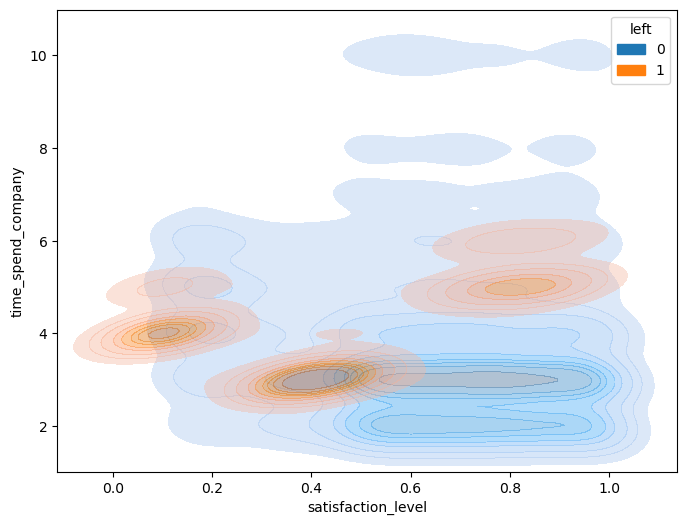

In [3]:
#Objetivo del grafico: 
#Buscar si los empleados con mayor o menor tiempo en la empresa renunciaban mas o menos. 
plt.figure(figsize=(8,6))

sns.kdeplot(
   data,
    x='satisfaction_level',
    y='time_spend_company',
    hue='left',
    fill=True,
    alpha=0.4
)

plt.show()
#Parece que los empleados con menos tiempo en la empresa son los que son los que mas terminan renunciando.

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

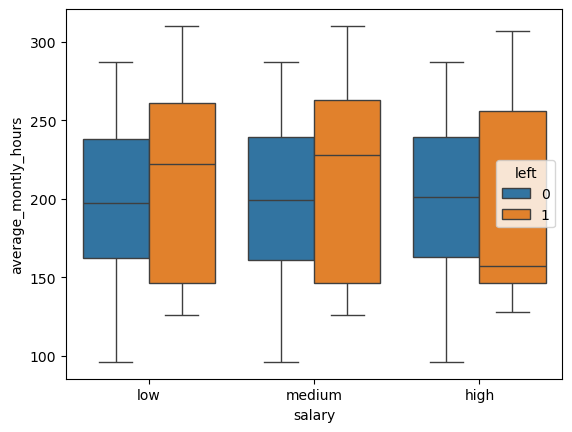

In [4]:
#Objetivo del grafico:
#Identificar si hay algun patron entre el salario, las horas mensualestrabajadas y las personas que renunciaron vs las que siguen trabajando en la empresa
sns.boxplot(data,x='salary', y='average_montly_hours', hue='left')
data.salary.value_counts()
#Parece que las personas que renuncian mas tienen un salario bajo o mediano y suelen trabajar mas horas en promedio que las persnas que no renuncian.
#Por otro lado, las personas que renuncian y tienen sueldos altos, trabajan por alguna razon menos que el promedio. 

In [6]:
# Cambiando valores 'categoricos' por numericos usando pd.get_dummies
data_dummies = pd.get_dummies(data, columns=['sales','salary'], dtype=int)
data_dummies

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [7]:
data_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales_IT               14999 non-null  int64  
 9   sales_RandD            14999 non-null  int64  
 10  sales_accounting       14999 non-null  int64  
 11  sales_hr               14999 non-null  int64  
 12  sales_management       14999 non-null  int64  
 13  sales_marketing        14999 non-null  int64  
 14  sales_product_mng      14999 non-null  int64  
 15  sa

* ### Use el método de K Vecinos más cercanos para generar un modelo predictivo. Para dicho fin, determine el valor óptimo de K evaluando distintas alternativas:         k = 1, 2, ...., 20 Asegúrese de respaldar su recomendación de la k óptima en base a una tabla que compare en cada caso las diversas precisiones comentadas en esta lección. 

In [8]:
y = data_dummies.left.values
x_data=data_dummies.drop(['left'], axis = 1)

In [9]:
x_data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0


In [10]:
# Normalizacion
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())

In [11]:
# Base de entrenamiento y prueba
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.30, random_state =1)

In [12]:
#Se investigo como generar un FOR para cada valor de k
# El mejor valor de K es el 2 ya que tiene el mejor puntaje en todas las metricas.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
resultados = []
for k in range(1,21):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(x_train, y_train)
    pred = modelo.predict(x_test)
    resultados.append([
        k,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred) 
        ])
tabla = pd.DataFrame(
    resultados,
    columns=[
        'K',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        ]
)
tabla

,K,Accuracy,Precision,Recall,F1 Score
0,1,0.961778,0.895833,0.952030,0.923077
1,2,0.957778,0.921698,0.901292,0.911381
2,3,0.945333,0.859966,0.923432,0.890569
3,4,0.946000,0.897824,0.875461,0.886502
4,5,0.939333,0.868972,0.880996,0.874943
5,6,0.944667,0.895735,0.871771,0.883590
6,7,0.941111,0.880223,0.874539,0.877372
7,8,0.939333,0.886559,0.857934,0.872011
8,9,0.932444,0.858456,0.861624,0.860037
9,10,0.934000,0.870877,0.852399,0.861538


In [13]:
#Modelo KNN (K vecinos mas cercano)


knn = KNeighborsClassifier(n_neighbors = 2)
knn.fit(x_train,y_train)
prediction = knn.predict(x_test)
print('Score: ', knn.score(x_test,y_test))

Score:  0.9577777777777777


* ### Elabore un mapa de calor para la matriz de confusión asociada al valor óptimo de k. Interprete verbalmente cada resultado mostrado en dicha matriz. 


In [14]:
#creacion de la matriz de confusion 
from sklearn.metrics import confusion_matrix
y_pred = prediction
y_true = y_test
cm = confusion_matrix(y_true, y_pred)
cm

array([[3333,   83],
       [ 107,  977]])

<function matplotlib.pyplot.show(close=None, block=None)>

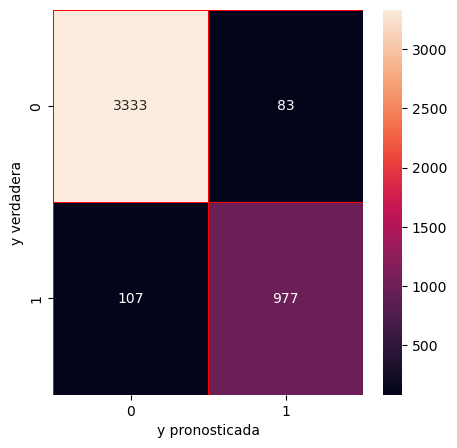

In [15]:
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap (cm, annot = True, linewidths = 0.5, linecolor = 'red', fmt = '.0f', ax = ax)
plt.xlabel('y pronosticada')
plt.ylabel('y verdadera')
plt.show


In [16]:
# Calculo de la precision global

correctos = cm[0,0] + cm[1,1]
incorrectos = cm[0,1] + cm[1,0]
precisionGlobal = correctos / (correctos + incorrectos)
precisionGlobal

np.float64(0.9577777777777777)

### Resultados
La matriz de confusión se divide en cuatro secciones:

* Verdaderos Negativos (3333): empleados que realmente no renunciaron y el modelo predijo correctamente que permanecerían en la empresa.
* Falsos Positivos (83): empleados que no renunciaron, pero el modelo predijo incorrectamente que abandonarían la empresa.
* Falsos Negativos (107): empleados que sí renunciaron, pero el modelo predijo que permanecerían en la empresa.
* Verdaderos Positivos (977): empleados que realmente renunciaron y el modelo los clasificó correctamente como empleados que abandonarían la empresa.
 
El modelo clasificó correctamente 4310 de los 4500 (95%) empleados del conjunto de prueba (3333 + 977), cometiendo únicamente 190 errores (83 falsos positivos y 107 falsos negativos). Esto indica un buen desempeño del clasificador, ya que identifica correctamente la mayoría de los empleados que permanecen y también una alta proporción de aquellos que abandonan la empresa.

* ### Obtenga e interprete la gráfica de la curva ROC para el valor óptimo de k.

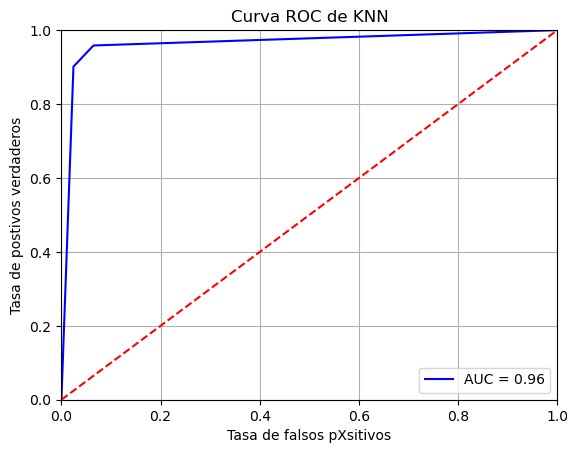

In [17]:
from sklearn.metrics import roc_curve 
from sklearn.metrics import auc

y_scores = knn.predict_proba(x_test)

fpr, tpr, threshold = roc_curve(y_test, y_scores[:,1])

roc_auc = auc(fpr, tpr)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr,tpr,'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc= 'lower right')
plt.plot([0,1], [0,1], 'r--', label='Clasificador aleatorio')
plt. xlim ([0,1])
plt.ylim ([0,1])
plt.ylabel('Tasa de postivos verdaderos')
plt.xlabel('Tasa de falsos pXsitivos')
plt. title('Curva ROC de KNN')
plt.grid(True)
plt.show()

### Resultado:

El valor esperado es que el AUC sea de 1, por lo que un valor de 0.96 se puede conciderar como excelente.